# Emotion Detection

Given an image of a facial expression, we want to determine what emotion is being portrayed. This is a multiclass classification problem as there are a total of 7 different emotions that we can classify instances as: angry, disgust, fear, happy, sad, surprised, and neutral. 

## Data Preprocessing and Analysis 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

2025-11-01 17:36:38.668843: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# import dataset
df = pd.read_csv('./data/fer2013.csv')

In [3]:
# get the number of observations and attributes
df.shape

(35887, 3)

In [4]:
[col for col in df.columns]

['emotion', 'pixels', 'Usage']

There are a total of 35887 images and 3 attributes: emotion, pixels, and usage.

In [5]:
print(np.unique(df['emotion']))

# assign class label to corresponding emotion index
emotions = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

[0 1 2 3 4 5 6]


The emotion attribute has 7 numerical labels where each number corresponds to a different emotion.

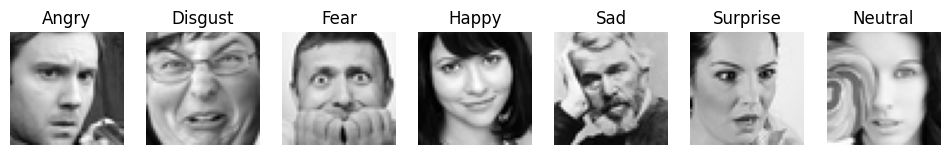

In [6]:
i, j = 0, 0
plt.figure(figsize=(12, 12))
while i < 7:
    if emotions[df['emotion'][j]] == emotions[i]:
        plt.subplot(1, 7, i + 1)
        plt.axis('off')
        plt.title(emotions[i])
        pixels = np.array(df['pixels'][j].split(' ')).reshape(48, 48).astype('uint8')
        plt.imshow(pixels, cmap = 'gray')
        i += 1
    j += 1
plt.show()

The pixels attribute contains 48 x 48 pixel grayscale images that each represent one of 7 facial expressions.

In [7]:
# remove column that tells us whether observation was used in train, test, or validation set
df.drop(columns=['Usage'], inplace = True)

The usage attribute tells us whether the data was used in the training, testing, or validation set. As we will split the data later, we no longer need the usage column and will remove it from the dataset. 

In [8]:
# check dataset for null values
df.isnull().sum()

emotion    0
pixels     0
dtype: int64

There are no null values in the dataset.

In [9]:
# check for duplicate entries
df[df.duplicated()]

,emotion,pixels
675,5,255 255 255 255 255 255 255 237 217 146 185 11...
718,2,114 95 82 84 85 120 108 97 83 64 68 85 80 86 1...
1145,5,205 204 205 205 204 203 203 203 202 202 203 20...
1266,3,201 218 246 178 74 62 63 78 85 83 71 65 64 67 ...
1289,5,238 69 24 32 34 33 27 30 41 49 60 64 47 65 80 ...
...,...,...
35826,2,200 201 199 197 198 199 199 198 197 196 194 19...
35833,5,254 254 254 254 254 253 252 254 113 36 62 69 6...
35874,5,43 43 51 73 94 97 102 95 99 107 126 144 154 17...
35875,5,248 251 239 144 102 95 82 77 91 138 153 145 14...


There are a total of 1793 duplicate entries.

In [10]:
# remove duplicates
df = df.drop_duplicates()
df.shape

(34094, 2)

After removing duplicate entries, there are a total of 34094 observations.

<BarContainer object of 7 artists>

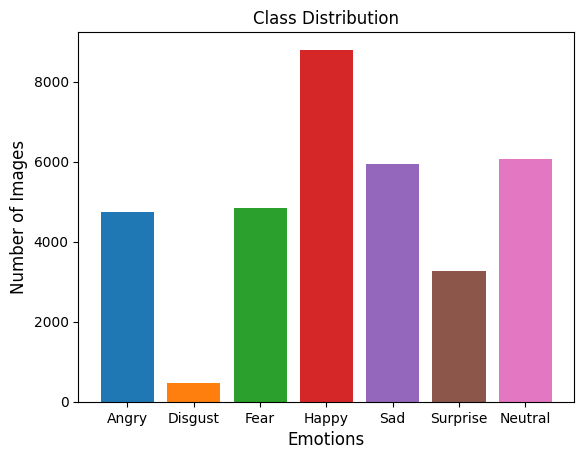

In [11]:
# plot distribution of class labels
plt.xlabel('Emotions', fontsize = 12)
plt.ylabel('Number of Images', fontsize = 12)
plt.title('Class Distribution')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.bar(emotions.values(), [list(df['emotion']).count(i) for i in np.unique(df['emotion'])], color = colors)

The emotion class with the most images is the happy class, followed by neutral, sad, fear, angry, surprise, and then disgust which has the least.

In [12]:
df.to_csv('./data/data-stage1.csv', index=False)

## Reshape Data   

Reshape image data from strings of pixels to Keras compatible numpy arrays.

In [13]:
# reshape pixels attribute from string into 2d numpy arrays
pixels = df['pixels'].apply(lambda x: x.split(" ")).tolist()
pixels = np.uint8(pixels)
pixels = pixels.reshape(pixels.shape[0], 48, 48, 1)
pixels.shape # (num of imgs, 48px, 48px, 1channel - greyscale)

(34094, 48, 48, 1)

## Split Data

Given X (the input image in pixels), we want to predict y (the emotion). We will split the dataset into 3 subsets, a training set, a testing set, and a validation set using an 80:10:10 split.

In [14]:
# split data into train, test, and validation sets
# 80% train, 10% test, 10% validation
X = pixels
y = df['emotion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 12)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state = 12)

## One Hot Encoding

Convert categorical data labels into numeric ones.

In [15]:
y_train_cat = to_categorical(y_train, num_classes=7)
y_test_cat = to_categorical(y_test, num_classes=7)
y_val_cat = to_categorical(y_val, num_classes=7)

## Normalize Data

As we are dealing with image data which is stored using pixel values, we will normalize the data instead of standardizing it. Since pixels can take values from 0 to 255, we will divide the pixel values of each image by 255 to get a range from 0 to 1.

In [16]:
X_train_normalized = X_train/255
X_test_normalized = X_test/255
X_val_normalized = X_val/255

## Save Processed Data

Save train, test, and validation arrays so they can be loaded into a new notebook for model training.

In [17]:
np.savez_compressed('./data/processed_data.npz',
                        X_train=X_train,
                        X_train_normalized=X_train_normalized,
                        X_test=X_test,
                        X_test_normalized=X_test_normalized,
                        X_val=X_val,
                        X_val_normalized=X_val_normalized,
                        y_train=y_train,
                        y_train_cat=y_train_cat,
                        y_test=y_test,
                        y_test_cat=y_test_cat,
                        y_val=y_val,
                        y_val_cat=y_val_cat
                   )